### Foreground comparison

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import json
import pandas
import os
import glob
from astropy import cosmology

In [2]:
fgfolder = '../data/'

In [116]:
fginfo_file = '../data/fgds_info.json'

with open(fginfo_file, 'r') as file:
    data = file.read()
fg_info = json.loads(data)

## kSZ

dl_ksz_doppler_alvarez.dat
16 kSZ templates


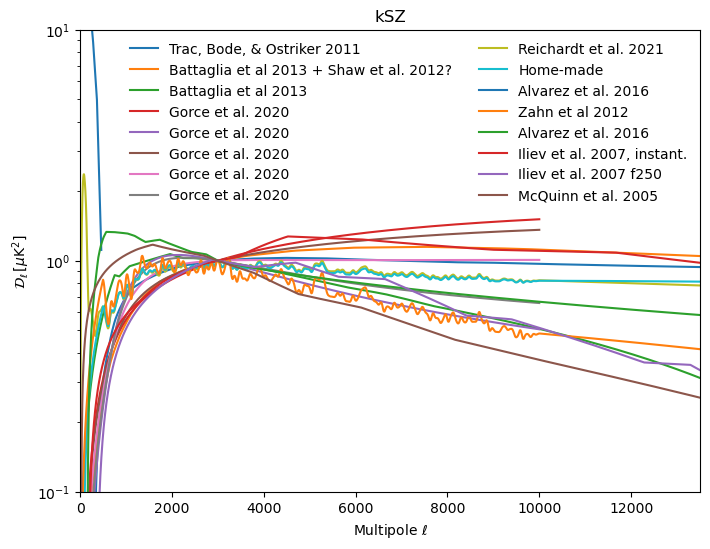

In [16]:
plt.figure(figsize=(8, 6))
nksz_temp = 0
ksz_keys = []
for k in fg_info.keys():
    if fg_info[k]['type'] == 'kSZ':
        ksz_keys.append(k)
        label = f"{fg_info[k]['authors']}"# {fg_info[k]['reference']}"
        try:
            if fg_info[k]['filetype'] in ['.dat', '.txt']:
                ells, cls = np.loadtxt(fgfolder+k, unpack=True)
                # print(cls.shape)
            elif fg_info[k]['filetype'] in ['.csv']:
                # print(k)
                data = pandas.read_csv(fgfolder+k)
                ells, cls = data.values.T
            plt.semilogy(ells, cls, label=label)
            if np.any(cls>10):
                print(k)
            nksz_temp += 1
        except OSError:
            print(f'{k} not found.')
plt.legend(ncol=2, frameon=False)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title('kSZ')
plt.ylim(0.1, 10)
plt.xlim(0, 13500)

print(f'{nksz_temp} kSZ templates')

dl_ksz_planck_2_13500.dat
13500 13500.0
2 2.0
{'authors': 'Planck', 'comments': 'Not sure.', 'extrapolated': False, 'filetype': '.dat', 'freq': None, 'lmax': 13500, 'lmin': 2, 'reference': None, 'type': 'kSZ', 'typebis': 'Total kSZ', 'used_in': 'Planck', 'website': '', 'normalised': 3000, 'from': None}


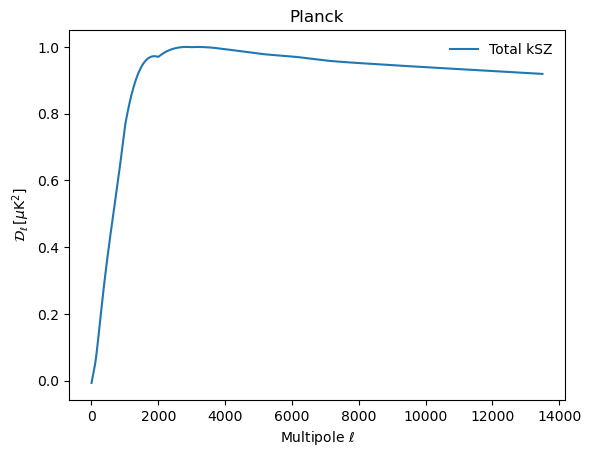

In [88]:
i = 1
k = "dl_ksz_planck_2_13500.dat"
# k = "dl_ksz_doppler_alvarez.dat"#"dl_ksz_patchy_Alvarez.csv"#ksz_keys[i]
print(k)

plt.figure()
if fg_info[k]['filetype'] in ['.dat', '.txt']:
    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
    # print(cls.shape)
elif fg_info[k]['filetype'] in ['.csv']:
    # print(k)
    data = pandas.read_csv(fgfolder+k)
    ells, cls = data.values.T
plt.plot(ells, cls, label=fg_info[k]['typebis'])
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(fg_info[k]['authors'])
print(fg_info[k]['lmax'], ells.max())
print(fg_info[k]['lmin'], ells.min())
# plt.xlim(1000, 9500)
# plt.ylim(0, 15)
plt.legend(frameon=False)
print(fg_info[k])


Homogeneous kSZ
dl_ksz_bat_13500.txt Battaglia et al 2010 Hydrodynamical simulations with instantaneous reion at z=10, s8 = 0.8, radiative cooling, SF, AGN and supernovae feedback. Patchy component ignored.
dl_ksz_hom_AG.dat Gorce et al. 2020 Late-time kSZ obtained with RF for Planck 2018 cosmology and zre=6.8, dz=1.2, alpha0=3.7, kappa=0.1
dl_ksz_homogeneous_shaw2012_extrapolated.dat Shaw et al. 2012 CSF model ie includes cooling and star formation.

Patchy kSZ
dl_ksz_patchy_bat_z10.dat Battaglia et al 2013 Patchy kSZ for z_mean = 10 and Delta_z = 1.05
dl_ksz_patchy_AG.dat Gorce et al. 2020 Patchy kSZ obtained with RF for Planck 2018 cosmology and zre=6.8, dz=1.2, alpha0=3.7, kappa=0.1
dl_ksz_patchy_spt.txt Zahn et al 2012 Semi-numerical simulations with excursion set, efficiency of ζ = 20, zre=7.5, Delta_z=4, rmax=5Mpc/h (Fig 2 of paper). Old name dl_ksz_oz_patchy_nolowell_20110708_norm1_fake25000.txt
dl_ksz_patchy_Alvarez.txt Alvarez et al. 2016 Instantaneous tanh reionisation with

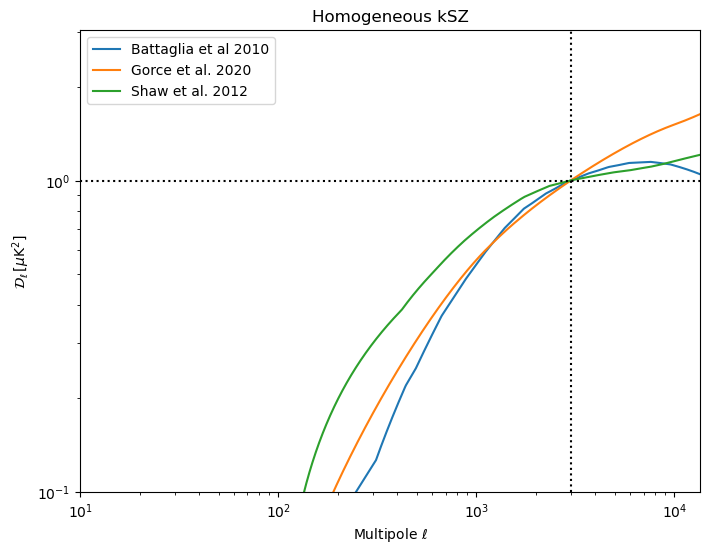

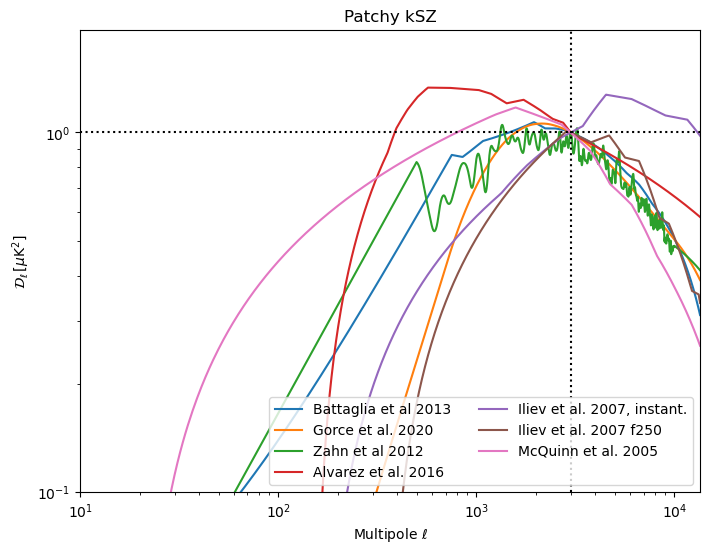

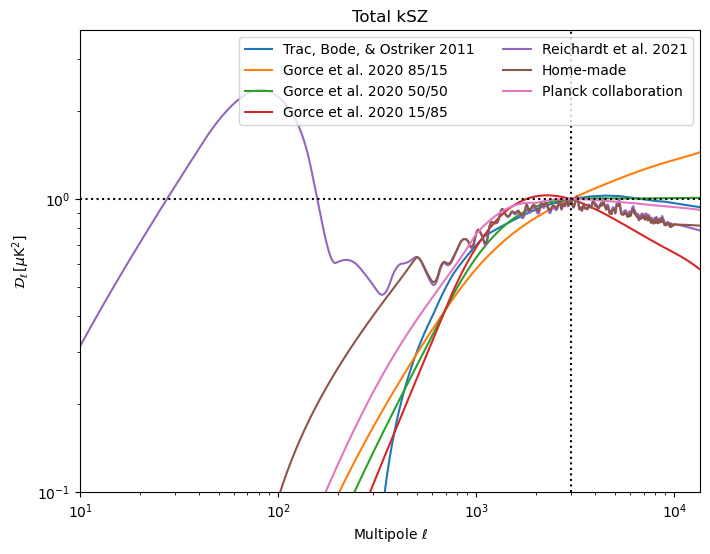

In [117]:
ksz_keys = []
nksz_temp = 0
for title in ["Homogeneous kSZ", "Patchy kSZ", "Total kSZ"]:
    print(f'\n{title}')
    plt.figure(figsize=(8,6))
    for k in fg_info.keys():
        if fg_info[k]['type'] == 'kSZ':
            ksz_keys.append(k)
            label = f"{fg_info[k]['authors']}"#, used in {fg_info[k]['used_in']}"# {fg_info[k]['reference']}"
            try:
                if fg_info[k]['filetype'] in ['.dat', '.txt']:
                    ells, cls = np.loadtxt(fgfolder+k, unpack=True)
                    # print(cls.shape)
                elif fg_info[k]['filetype'] in ['.csv']:
                    # print(k)
                    data = pandas.read_csv(fgfolder+k)
                    ells, cls = data.values.T
                if fg_info[k]['typebis'] in [title, 'OV']:
                    i3000 = np.argmin(np.abs(ells-3000.))
                    plt.loglog(ells, cls/cls[i3000], label=label)
                    print(k, fg_info[k]['authors'], fg_info[k]['comments'])
                    nksz_temp += 1
                    if not np.isclose(fg_info[k]['lmax'], ells.max()) or (not np.isclose(fg_info[k]['lmin'], ells.min())):
                        print(fg_info[k]['lmax'], ells.max(), fg_info[k]['lmin'], ells.min())
            except OSError:
                print(f'{k} not found.')
    plt.legend(ncol=2 if nksz_temp>4 else 1, frameon=True)
    plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
    plt.xlabel(r'Multipole $\ell$')
    plt.title(title)
    plt.axvline(3000, color='k', ls=':')
    plt.axhline(1., color='k', ls=':')
    plt.ylim(bottom=0.1)
    plt.xlim(10, 13500)

print(f'\n{nksz_temp}')
for k in glob.glob('../data/dl_ksz*'):
    if os.path.basename(k) not in ksz_keys:
        print(k)

dl_ksz_tbo.dat dl_ksz_tbo.txt
dl_ksz_bat_13500.dat dl_ksz_bat_13500.txt
dl_ksz_patchy_Alvarez.csv dl_ksz_patchy_Alvarez.txt
dl_ksz_patchy_iliev.csv dl_ksz_patchy_iliev.txt
dl_ksz_patchy_iliev_f250.dat dl_ksz_patchy_iliev_f250.txt
dl_ksz_patchy_mcquinn.csv dl_ksz_patchy_mcquinn.txt


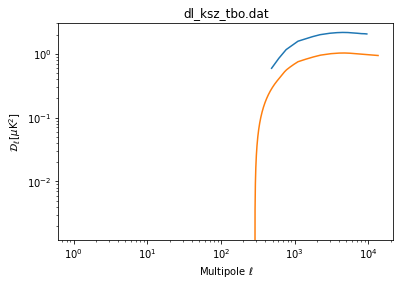

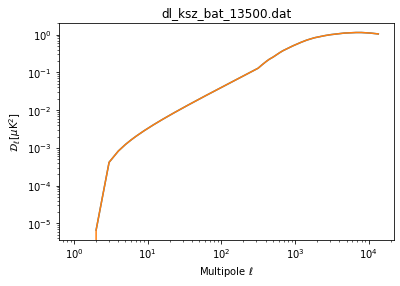

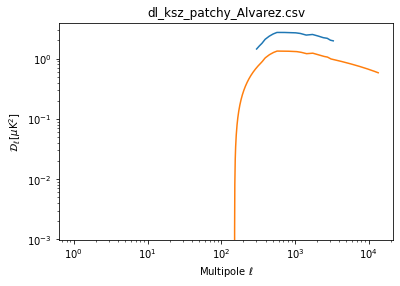

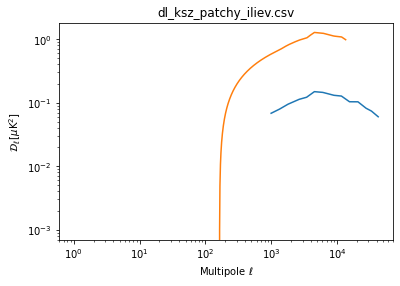

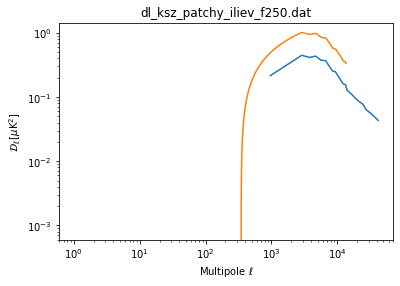

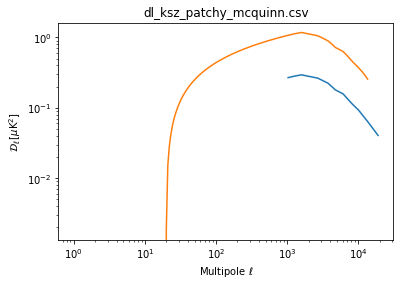

In [ ]:
## extrapolation

# l1 = np.arange(1, 13501)
# for k in fg_info.keys():
#     if fg_info[k]['type'] == 'kSZ':
#         if fg_info[k]['filetype'] in ['.dat', '.txt']:
#             ells, dls = np.loadtxt(fgfolder+k, unpack=True)
#             # print(cls.shape)
#         elif fg_info[k]['filetype'] in ['.csv']:
#             # print(k)
#             data = pandas.read_csv(fgfolder+k)
#             ells, dls = data.values.T
#         if (ells.min() > l1.min() or ells.max() < l1.max()) and (ells.max() >= 3000.):
#             dl_interp = interp1d(np.log10(ells), dls, bounds_error=False, fill_value='extrapolate')
#             dl1 = dl_interp(np.log10(l1))
#             dl1 /= dl_interp(np.log10(3000))
#             dl1[dl1<0.] = 0.
#             plt.figure()
#             plt.loglog(ells, dls)
#             plt.plot(l1, dl1)
#             plt.title(k)
#             plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
#             plt.xlabel(r'Multipole $\ell$')
#             plt.title(k)
#             # plt.ylim(bottom=0.1)
#             print(k, k[:-4]+'.txt')
#             np.savetxt(fgfolder+k[:-4]+'.txt', np.c_[np.r_[0, l1], np.r_[0, dl1]], header='l dl [uK2]')

## Identification of Planck template

(0.1, 1.391095663581087)

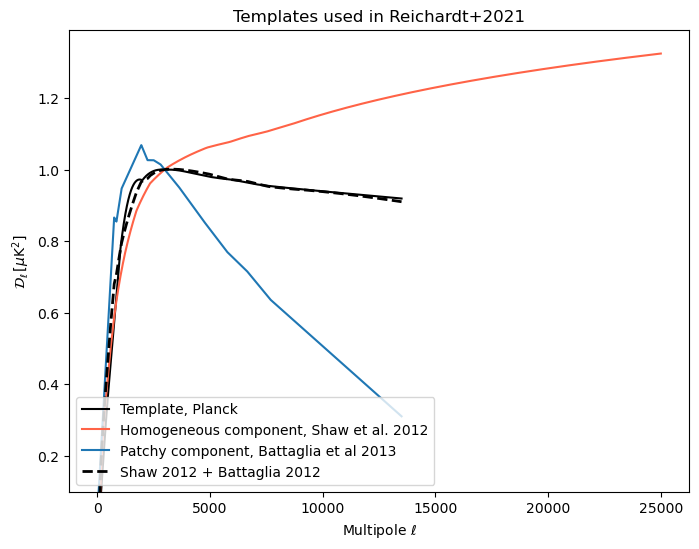

In [110]:
plt.figure(figsize=(8,6))
for u, (k, title, color) in enumerate(zip(["dl_ksz_planck_2_13500.dat", "dl_ksz_homogeneous_shaw2012_extrapolated.dat", "dl_ksz_patchy_bat_z10.dat"],
                                   ["Template", "Homogeneous component", "Patchy component"],
                                   ['k', 'tomato', 'C0'])):
    label = f"{title}, {fg_info[k]['authors']}"# {fg_info[k]['reference']}"
    try:
        if fg_info[k]['filetype'] in ['.dat', '.txt']:
            ells, cls = np.loadtxt(fgfolder+k, unpack=True)
            # print(cls.shape)
        elif fg_info[k]['filetype'] in ['.csv']:
            # print(k)
            data = pandas.read_csv(fgfolder+k)
            ells, cls = data.values.T
        # i3000 = np.argmin(np.abs(ells-3000.))
        plt.plot(ells, cls, label=label, color=color)
    except OSError:
        print(f'{k} not found.')

perc = 1/3
l1, dlp = np.loadtxt(fgfolder+"dl_ksz_patchy_bat_z10.dat", unpack=True)
dlh = interp1d(np.loadtxt(fgfolder+"dl_ksz_homogeneous_shaw2012_extrapolated.dat", unpack=True)[0], np.loadtxt(fgfolder+"dl_ksz_homogeneous_shaw2012_extrapolated.dat", unpack=True)[1], bounds_error=False, fill_value='extrapolate')(l1)
dlt = perc * dlp + (1-perc) * dlh
plt.plot(l1, dlt, ls='--', color='k', lw=2., label='Shaw 2012 + Battaglia 2012')

plt.legend(loc='lower left')
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title('Templates used in Reichardt+2021')
plt.ylim(bottom=0.1)

## Identification of SPT templates

(0.1, 3.52613235853975)

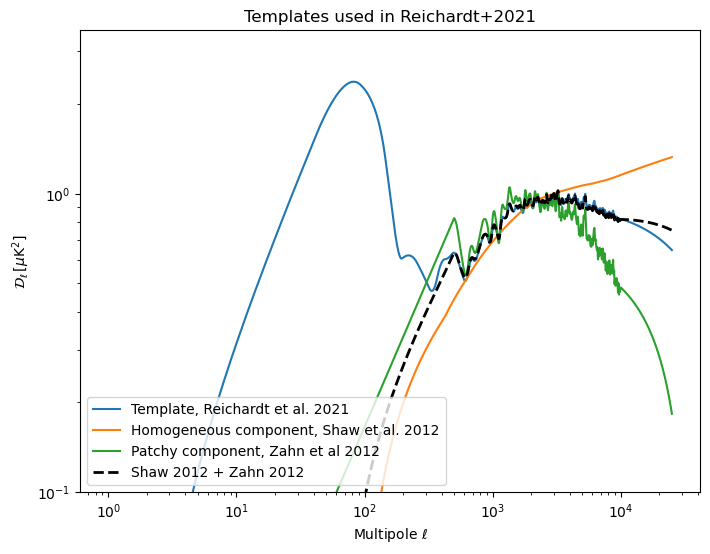

In [ ]:
plt.figure(figsize=(8,6))
for u, (k, title) in enumerate(zip(["dl_ksz_spt_2021.txt", "dl_ksz_homogeneous_shaw2012_extrapolated.dat", "dl_ksz_oz_patchy_nolowell_20110708_norm1_fake25000.txt"],
                                   ["Template", "Homogeneous component", "Patchy component"])):
    label = f"{title}, {fg_info[k]['authors']}"# {fg_info[k]['reference']}"
    try:
        if fg_info[k]['filetype'] in ['.dat', '.txt']:
            ells, cls = np.loadtxt(fgfolder+k, unpack=True)
            # print(cls.shape)
        elif fg_info[k]['filetype'] in ['.csv']:
            # print(k)
            data = pandas.read_csv(fgfolder+k)
            ells, cls = data.values.T
        # i3000 = np.argmin(np.abs(ells-3000.))
        plt.loglog(ells, cls, label=label)
    except OSError:
        print(f'{k} not found.')

l1, dl1 = np.loadtxt(fgfolder+"dl_ksz_oz_patchy_nolowell_20110708_norm1_fake25000.txt", unpack=True)
dl1 += np.loadtxt(fgfolder+"dl_ksz_homogeneous_shaw2012_extrapolated.dat", unpack=True)[1]
plt.plot(l1, dl1/dl1[3000], ls='--', color='k', lw=2., label='Shaw 2012 + Zahn 2012')

plt.legend(loc='lower left')
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title('Templates used in Reichardt+2021')
plt.ylim(bottom=0.1)

dl_ksz_patchy_bat_z10.dat Battaglia et al 2013 Patchy kSZ for z_mean = 10 and Delta_z = 1.05
dl_ksz_bat_13500.txt Battaglia et al 2013 + Shaw et al. 2012? Unidentified, possibly Battaglia et al 2013 + Shaw et al. 2012 but does not really look like it.
dl_homogeneous_ksz_shaw2012_extrapolated.dat Shaw et al. 2012 Homogeneous kSZ from Shaw et al. 2012, for CSF model (Fig. 5, in blue) ie includes cooling and star formation. Extrapolated in log to 1<=l<=25000. Used in total template of Reichardt+2021.


(0.1, 2.4384352019314077)

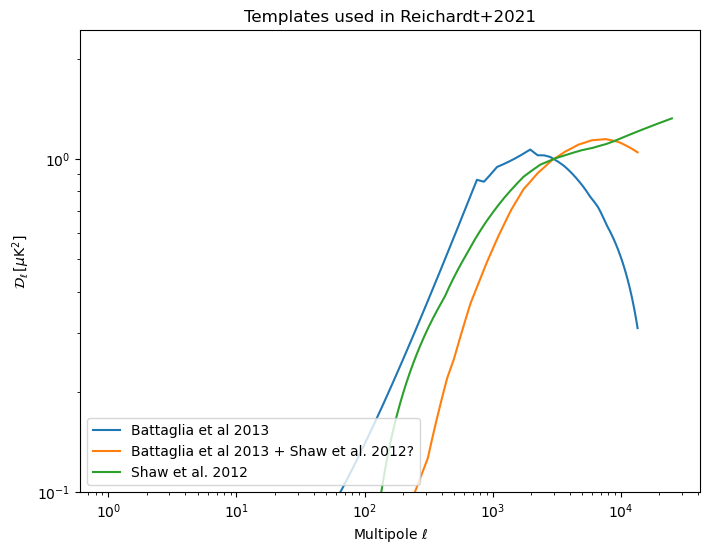

In [9]:
plt.figure(figsize=(8,6))
for k in ["dl_ksz_patchy_bat_z10.dat", "dl_ksz_bat_13500.txt", "dl_homogeneous_ksz_shaw2012_extrapolated.dat"]:
    if fg_info[k]['type'] == 'kSZ':
        label = f"{fg_info[k]['authors']}"
        try:
            if fg_info[k]['filetype'] in ['.dat', '.txt']:
                ells, cls = np.loadtxt(fgfolder+k, unpack=True)
                # print(cls.shape)
            elif fg_info[k]['filetype'] in ['.csv']:
                # print(k)
                data = pandas.read_csv(fgfolder+k)
                ells, cls = data.values.T
            # i3000 = np.argmin(np.abs(ells-3000.))
            plt.loglog(ells, cls, label=label)
            print(k, fg_info[k]['authors'], fg_info[k]['comments'])
        except OSError:
            print(f'{k} not found.')

# l1, dl1 = np.loadtxt(fgfolder+'dl_ksz_bat_13500.dat', unpack=True)
# dl1 += np.loadtxt(fgfolder+"dl_homogeneous_ksz_shaw2012_extrapolated.dat", unpack=True)[1]
# plt.plot(l1, dl1/dl1[3000], ls='--', color='k', lw=2., label='Shaw 2012 + Zahn 2012')

plt.legend(loc='lower left')
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title('Templates used in Reichardt+2021')
plt.ylim(bottom=0.1)

dl_ksz_bat_13500.txt Battaglia et al 2013 + Shaw et al. 2012? Unidentified, possibly Battaglia et al 2013 + Shaw et al. 2012 but does not really look like it.
dl_ksz_spt_2021.txt Reichardt et al. 2021 Includes low-l OV contribution, homogeneous from Shaw+2012 CSF model and patchy Zahn+2012, added to equal weights. Initially called dl_ksz_CSFplusPATCHY_13sep2011_norm1_fake25000.txt
dl_homogeneous_ksz_shaw2012_extrapolated.dat Shaw et al. 2012 Homogeneous kSZ from Shaw et al. 2012, for CSF model (Fig. 5, in blue) ie includes cooling and star formation. Extrapolated in log to 1<=l<=25000. Used in total template of Reichardt+2021.
dl_ksz_oz_patchy_nolowell_20110708_norm1_fake25000.txt Zahn et al 2012 Semi-numerical simulations with excursion set, efficiency of ζ = 20, zre=7.5, Delta_z=4, rmax=5Mpc/h (Fig 2 of paper)


(0.1, 4.488815483980753)

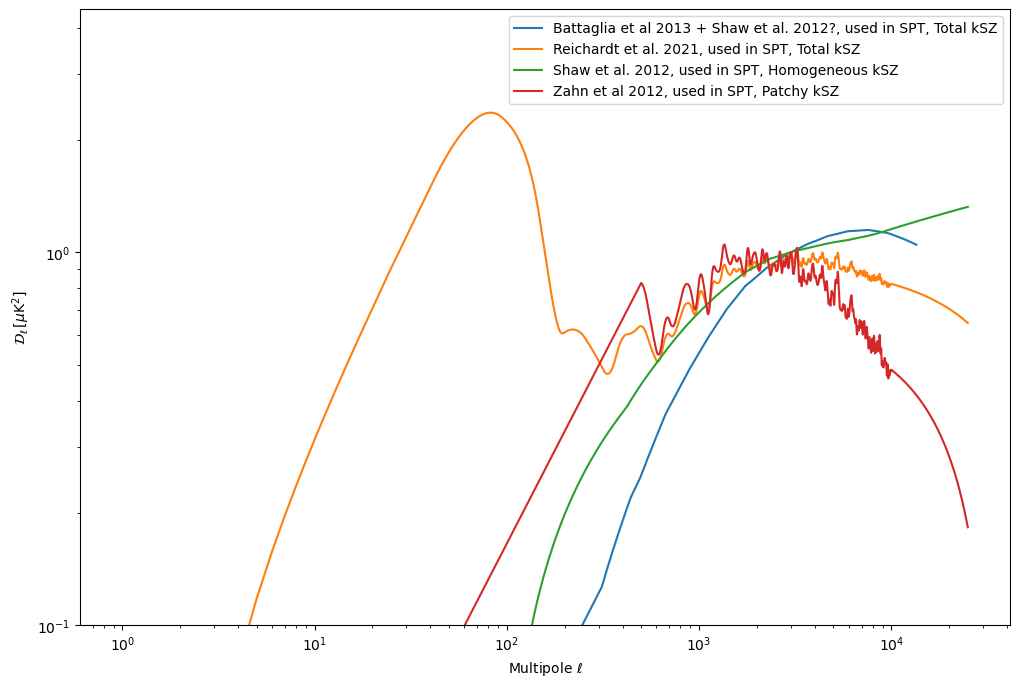

In [13]:
plt.figure(figsize=(12,8))
nksz_temp = 0
ksz_keys = []
for k in fg_info.keys():
    if fg_info[k]['type'] == 'kSZ':
        ksz_keys.append(k)
        label = f"{fg_info[k]['authors']}, used in {fg_info[k]['used_in']}, {fg_info[k]['typebis']}"# {fg_info[k]['reference']}"
        try:
            if fg_info[k]['filetype'] in ['.dat', '.txt']:
                ells, cls = np.loadtxt(fgfolder+k, unpack=True)
                # print(cls.shape)
            elif fg_info[k]['filetype'] in ['.csv']:
                # print(k)
                data = pandas.read_csv(fgfolder+k)
                ells, cls = data.values.T
            if 'Shaw' in fg_info[k]['authors'] or 'Zahn' in fg_info[k]['authors'] or 'Reichardt' in fg_info[k]['authors']:# or 'Alvarez' in fg_info[k]['authors']:
                i3000 = np.argmin(np.abs(ells-3000.))
                plt.loglog(ells, cls/cls[i3000], label=label)
                print(k, fg_info[k]['authors'], fg_info[k]['comments'])
                nksz_temp += 1
        except OSError:
            print(f'{k} not found.')

# l1, dl1 = np.loadtxt(fgfolder+"dl_ksz_patchy_bat_z10.dat", unpack=True)
# dl1 += np.loadtxt(fgfolder+"dl_homogeneous_ksz_shaw2012_extrapolated.dat", unpack=True)[1]
# plt.plot(l1, dl1/dl1[3000], ls='--', color='k', lw=2., label='Shaw 2012 + Zahn 2012')

plt.legend()#ncol=2 if nksz_temp>4 else 1, frameon=False)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
# plt.title('SPT spectra')
plt.ylim(bottom=0.1)

dl_ksz_bat_13500.txt Battaglia et al 2013 + Shaw et al. 2012? Unidentified, possibly Battaglia et al 2013 + Shaw et al. 2012 but does not really look like it.
dl_ksz_patchy_bat_z10.dat Battaglia et al 2013 Patchy kSZ for z_mean = 10 and Delta_z = 1.05
dl_ksz_spt_2021.txt Reichardt et al. 2021 Includes low-l OV contribution, homogeneous from Shaw+2012 CSF model and patchy Zahn+2012, added to equal weights. Initially called dl_ksz_CSFplusPATCHY_13sep2011_norm1_fake25000.txt
dl_homogeneous_ksz_shaw2012_extrapolated.dat Shaw et al. 2012 Homogeneous kSZ from Shaw et al. 2012, for CSF model (Fig. 5, in blue) ie includes cooling and star formation. Extrapolated in log to 1<=l<=25000. Used in total template of Reichardt+2021.
dl_ksz_oz_patchy_nolowell_20110708_norm1_fake25000.txt Zahn et al 2012 Semi-numerical simulations with excursion set, efficiency of ζ = 20, zre=7.5, Delta_z=4, rmax=5Mpc/h (Fig 2 of paper)


(0.01, 5)

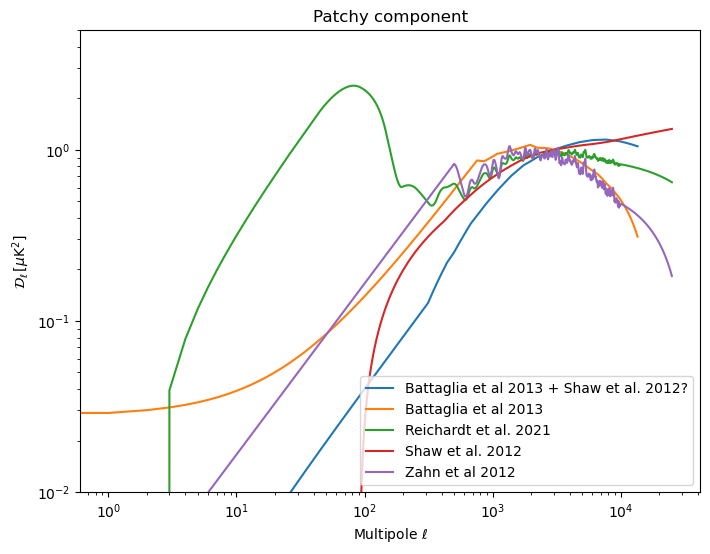

In [14]:
plt.figure(figsize=(8,6))
nksz_temp = 0
ksz_keys = []
for k in fg_info.keys():
    if fg_info[k]['type'] == 'kSZ':
        ksz_keys.append(k)
        label = f"{fg_info[k]['authors']}"# {fg_info[k]['reference']}"
        try:
            if fg_info[k]['filetype'] in ['.dat', '.txt']:
                ells, cls = np.loadtxt(fgfolder+k, unpack=True)
                # print(cls.shape)
            elif fg_info[k]['filetype'] in ['.csv']:
                # print(k)
                data = pandas.read_csv(fgfolder+k)
                ells, cls = data.values.T
            if fg_info[k]['used_in'] == 'SPT':
                i3000 = np.argmin(np.abs(ells-3000.))
                plt.loglog(ells, cls/cls[i3000], label=label)
                print(k, fg_info[k]['authors'], fg_info[k]['comments'])
                nksz_temp += 1
        except OSError:
            print(f'{k} not found.')
plt.legend()#ncol=2 if nksz_temp>4 else 1, frameon=False)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title(title)
plt.ylim(0.01,5)



## Templates for SPT+ACT+Planck analysis

Different contributions of patchy component, for reference random forest kSZ

In [75]:
from emul_sz import emulator

2024-12-09 16:20:05.201989: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-09 16:20:07.478247: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-09 16:20:07.478305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-09 16:20:07.502180: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-09 16:20:07.799240: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-09 16:20:07.808604: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [76]:
pksz_emulator = emulator(seed="RF_KSZ_patchy", verbose=False)
hksz_emulator = emulator(seed="RF_KSZ_late", verbose=False)

In [77]:
# Use Planck 2018 cosmology
cos = cosmology.Planck18
cosmo_dict = {
    'ombh2': cos.Ob0*cos.h**2,
    'omch2': (cos.Om0-cos.Ob0)*cos.h**2,
    'ns': 0.9677,
    '100theta': 0.01041*100.,
    'logAs': 3.044,
    'bias_SZ': 6.07113e-01,
    'alpha_SZ': 1.79,
    'mnu': 0.015,
    'zre': 6.8,
    'dz': 1.2,
    'alpha0': 3.7,
    'kappa': 0.1,
    }

0 9999 3000


Text(0.5, 0, 'Multipole $\\ell$')

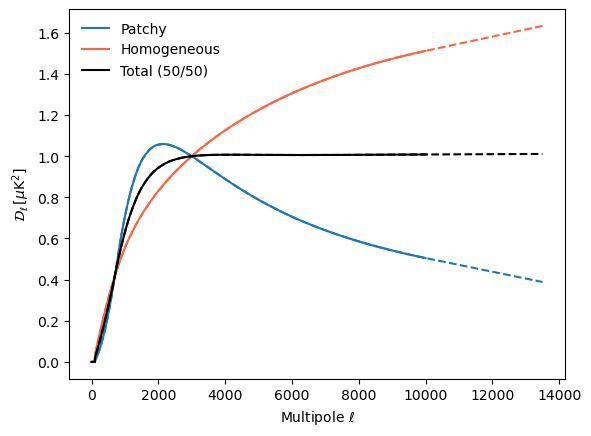

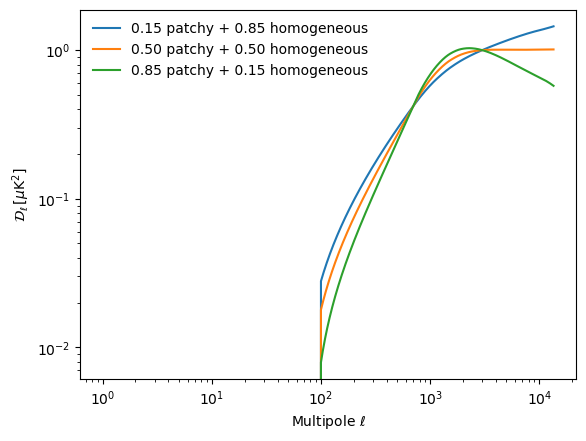

In [113]:
l1 = np.arange(0, 10000) # emulator trained only up to l=10000
print(l1.min(), l1.max(), l1[3000])
l2 = np.arange(0, 13501) # emulator trained only up to l=10000
dlp = pksz_emulator.get_cls(
    cosmo_dict=cosmo_dict,
    ells=l1,
    with_unit=True
)
dlp_interp = interp1d(l1, dlp/dlp[3000], fill_value='extrapolate', bounds_error=False)
np.savetxt(fgfolder+'dl_ksz_patchy_AG.dat', np.c_[l2, dlp_interp(l2)], header='l dl [uK2]')
dlh = hksz_emulator.get_cls(
    cosmo_dict=cosmo_dict,
    ells=l1,
    with_unit=True
)
dlh_interp = interp1d(l1, dlh/dlh[3000], fill_value='extrapolate', bounds_error=False)
np.savetxt(fgfolder+'dl_ksz_hom_AG.dat', np.c_[l2, dlh_interp(l2)], header='l dl [uK2]')

plt.figure()
plt.plot(l1, dlp/dlp[3000], label='Patchy', color='C0')
plt.plot(l2, dlp_interp(l2), color='C0', ls='--')
plt.plot(l1, dlh/dlh[3000], label='Homogeneous', color='tomato')
plt.plot(l2, dlh_interp(l2), color='tomato', ls='--')
plt.plot(l1, 0.5*(dlp/dlp[3000]+dlh/dlh[3000]), label='Total (50/50)', color='k')
plt.plot(l2, 0.5*(dlh_interp(l2)+dlp_interp(l2)), color='k', ls='--')
plt.legend(frameon=False)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')

plt.figure()
for perc in [0.15, 0.5, 0.85]:
    dlt = perc*dlp_interp(l2) + (1-perc)*dlh_interp(l2)
    dlt /= dlt[3000]
    plt.loglog(l2, dlt, label=f'{perc:.2f} patchy + {1-perc:.2f} homogeneous')
    np.savetxt(fgfolder+f'dl_ksz_total_AG_{int(perc*100)}patchy.dat', np.c_[l2, dlt/dlt[3000]], header='l dl [uK2]')
plt.legend(frameon=False)
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')

50% patchy + 50% homogeneous, with and without Doppler effect

(0.1, 3.52613235853975)

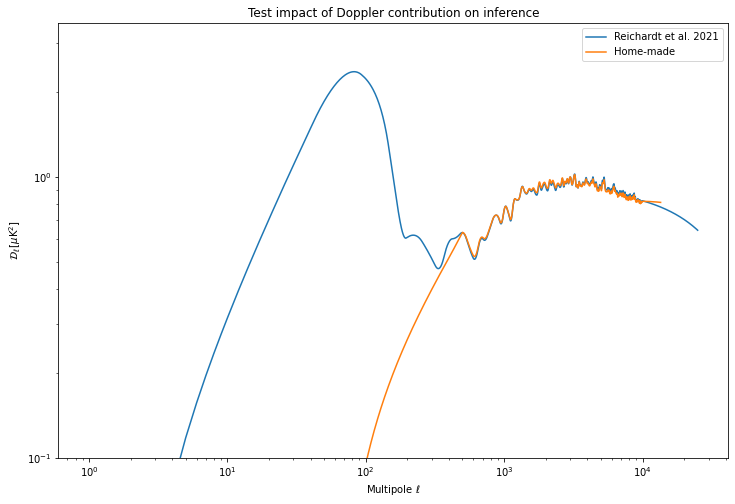

In [157]:
plt.figure(figsize=(12,8))
k = "dl_ksz_spt_2021.txt"
label = f"{fg_info[k]['authors']}"
ells, dls = np.loadtxt(fgfolder+k, unpack=True)
plt.loglog(ells, dls, label=label)

# l0 = np.arange(0, 13501)
# l1, dl1 = np.loadtxt(fgfolder+"dl_ksz_oz_patchy_nolowell_20110708_norm1_fake25000.txt", unpack=True)
# dl1_interp = interp1d(l1, dl1)(l0)
# l2, dl2 = np.loadtxt(fgfolder+"dl_homogeneous_ksz_shaw2012_extrapolated.dat", unpack=True)
# dl2_interp = interp1d(l2, dl2)(l0)
# dltot = dl1_interp+dl2_interp
# plt.plot(l0, dltot/dltot[3000], ls='--', color='k', lw=2., label='Shaw 2012 + Zahn 2012')
# np.savetxt(fgfolder+'dl_ksz_spt_2021_no_doppler.txt', np.c_[l0, dltot/dltot[3000]], header='l dl [uK2]')
k = 'dl_ksz_spt_2021_no_doppler.txt'
label = f"{fg_info[k]['authors']}"
ells, dls = np.loadtxt(fgfolder+k, unpack=True)
plt.loglog(ells, dls, label=label)

plt.legend()
plt.ylabel(r'$\mathcal{D}_\ell\,[\mu\mathrm{K}^2]$')
plt.xlabel(r'Multipole $\ell$')
plt.title('Test impact of Doppler contribution on inference')
plt.ylim(bottom=0.1)